This notebook builds a simple Monte Carlo framework to price European options.

The idea is to simulate many possible future paths for the underlying asset, compute the option payoff at maturity, and discount the average payoff back to today. Monte Carlo is useful because the same logic can be extended to more complex derivatives where closed-form formulas are not available.

In this project, the underlying price follows a **Geometric Brownian Motion (GBM)** under the risk-neutral measure.

Main parameters:

- **S0**: initial stock price
- **K**: strike price
- **T**: time to maturity in years
- **r**: risk-free interest rate
- **sigma**: volatility of the underlying

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

np.random.seed(42)

In [2]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20

n_steps = 252
n_simulations = 20000

Under GBM, the stock price evolves as:

\[
dS_t = r S_t dt + \sigma S_t dW_t
\]

In discrete time, I simulate the log-returns and build the paths step by step.

In [3]:
def simulate_gbm_paths(S0, T, r, sigma, n_steps, n_simulations):
    dt = T / n_steps

    z = np.random.normal(0, 1, size=(n_simulations, n_steps))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z

    log_paths = np.cumsum(increments, axis=1)
    log_paths = np.hstack([np.zeros((n_simulations, 1)), log_paths])

    paths = S0 * np.exp(log_paths)
    return paths

In [4]:
paths = simulate_gbm_paths(S0, T, r, sigma, n_steps, n_simulations)
paths[:5, :5]


array([[100.        , 100.63974344, 100.47654577, 101.31185987,
        103.28693597],
       [100.        , 102.72195669, 104.07926536, 102.11805655,
        101.50903739],
       [100.        ,  99.19542634,  98.60024559,  97.87873731,
         96.83060631],
       [100.        , 100.63543729, 100.8820708 ,  99.8088618 ,
        100.70536725],
       [100.        , 101.34315728, 100.67405023, 102.37112859,
        102.6385193 ]])

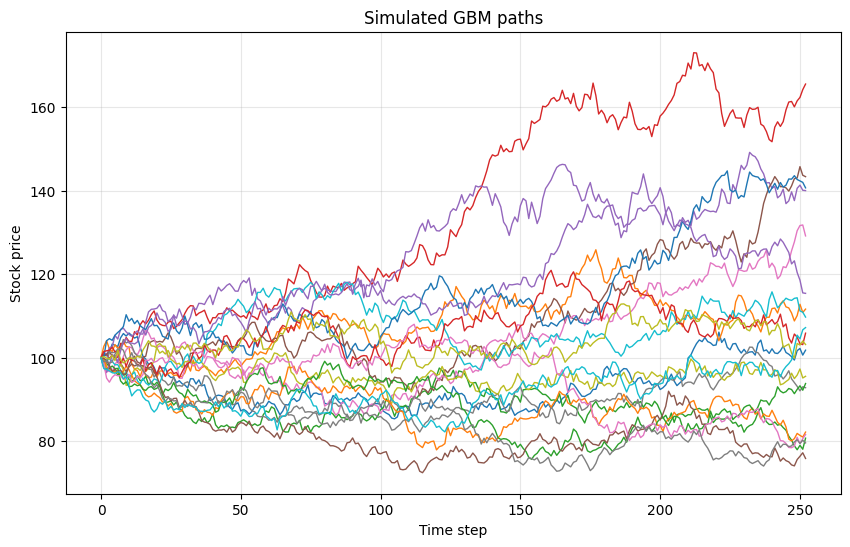

In [5]:
plt.figure(figsize=(10, 6))

for i in range(20):
    plt.plot(paths[i], linewidth=1)

plt.title("Simulated GBM paths")
plt.xlabel("Time step")
plt.ylabel("Stock price")
plt.grid(True, alpha=0.3)
plt.show()

**Monte Carlo pricing**

Call payoff: \( \max(S_T - K, 0) \)

Put payoff: \( \max(K - S_T, 0) \)

The Monte Carlo price is the discounted average payoff.

In [6]:
def monte_carlo_call_price(S0, K, T, r, sigma, n_steps, n_simulations):
    paths = simulate_gbm_paths(S0, T, r, sigma, n_steps, n_simulations)
    terminal_prices = paths[:, -1]

    payoffs = np.maximum(terminal_prices - K, 0)
    price = np.exp(-r * T) * np.mean(payoffs)

    return price

def monte_carlo_put_price(S0, K, T, r, sigma, n_steps, n_simulations):
    paths = simulate_gbm_paths(S0, T, r, sigma, n_steps, n_simulations)
    terminal_prices = paths[:, -1]

    payoffs = np.maximum(K - terminal_prices, 0)
    price = np.exp(-r * T) * np.mean(payoffs)

    return price

In [7]:
mc_call = monte_carlo_call_price(S0, K, T, r, sigma, n_steps, n_simulations)
mc_put = monte_carlo_put_price(S0, K, T, r, sigma, n_steps, n_simulations)

print(f"Monte Carlo call price: {mc_call}")
print(f"Monte Carlo put price:  {mc_put}")

Monte Carlo call price: 10.429340037604359
Monte Carlo put price:  5.586635206770078


**Black-Scholes formulas**

For European options BS gives a theoretical price, useful as a benchmark to check if the Monte Carlo estimate is reasonable.

In [8]:
def black_scholes_call(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def black_scholes_put(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return put_price

In [9]:
bs_call = black_scholes_call(S0, K, T, r, sigma)
bs_put = black_scholes_put(S0, K, T, r, sigma)

print(f"Black-Scholes call price: {bs_call}")
print(f"Black-Scholes put price:  {bs_put}")

Black-Scholes call price: 10.450583572185565
Black-Scholes put price:  5.573526022256971


In [10]:
comparison = pd.DataFrame({
    "Option": ["Call", "Put"],
    "Monte Carlo": [mc_call, mc_put],
    "Black-Scholes": [bs_call, bs_put]
})

comparison["Absolute Error"] = (comparison["Monte Carlo"] - comparison["Black-Scholes"]).abs()
comparison

,Option,Monte Carlo,Black-Scholes,Absolute Error
0,Call,10.429340,10.450584,0.021244
1,Put,5.586635,5.573526,0.013109


The Monte Carlo prices should be close to the Black-Scholes values.  
A small difference is normal because the simulation uses a finite number of paths.

Here I check how the estimated prices move as I increase the number of simulated paths.

In [17]:
simulation_grid = [100, 500, 1000, 5000, 10000, 20000, 50000, 100000]

mc_call_prices = []
mc_put_prices = []
errors = []

for n_sim in simulation_grid:
    call_price = monte_carlo_call_price(S0, K, T, r, sigma, n_steps, n_sim)
    put_price = monte_carlo_put_price(S0, K, T, r, sigma, n_steps, n_sim)

    mc_call_prices.append(call_price)
    mc_put_prices.append(put_price)

    errors.append((abs(call_price-bs_call)+abs(put_price-bs_put))/2)

In [18]:
convergence_df = pd.DataFrame({
    "n_simulations": simulation_grid,
    "MC Call": mc_call_prices,
    "MC Put": mc_put_prices,
    "Mean Err": errors
})

convergence_df

,n_simulations,MC Call,MC Put,Mean Err
0,100,8.619041,4.607458,1.398806
1,500,11.374233,5.629180,0.489652
2,1000,10.324030,6.005320,0.279174
3,5000,10.692100,5.645819,0.156905
4,10000,10.539772,5.576989,0.046326
5,20000,10.582391,5.607411,0.082846
6,50000,10.472741,5.568117,0.013783
7,100000,10.437447,5.543836,0.021414


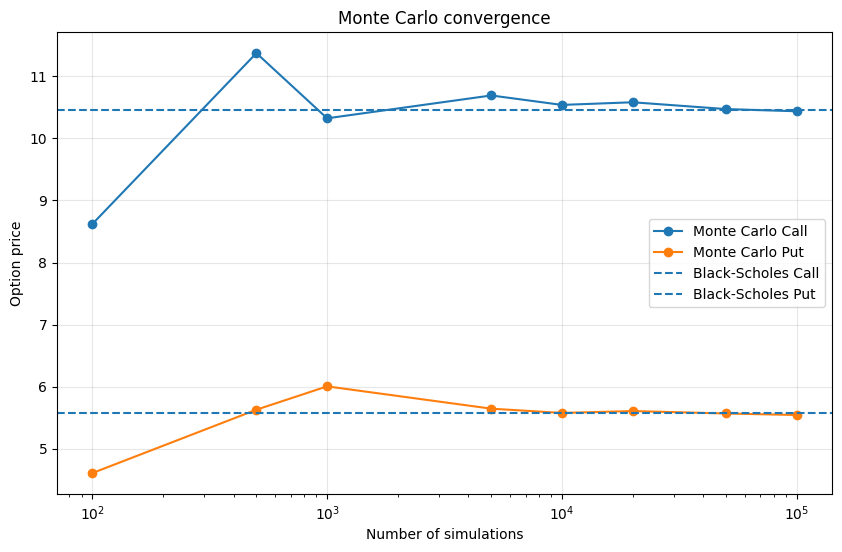

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(simulation_grid, mc_call_prices, marker="o", label="Monte Carlo Call")
plt.plot(simulation_grid, mc_put_prices, marker="o", label="Monte Carlo Put")

plt.axhline(bs_call, linestyle="--", label="Black-Scholes Call")
plt.axhline(bs_put, linestyle="--", label="Black-Scholes Put")

plt.title("Monte Carlo convergence")
plt.xlabel("Number of simulations")
plt.ylabel("Option price")
plt.xscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Monte Carlo estimates become more stable when the number of simulations grows.
The convergence is not perfectly smooth because there is still random sampling error, but the estimates move around the Black-Scholes benchmark and usually get closer with more paths.

Some simple next steps could be:

- estimate Greeks with finite differences
- price an Asian option with the same simulation logic